In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ====================== LOADING DATA ======================

file_path = 'players_data_light-2024_2025.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Dataset loaded successfully! Shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print("Error: CSV file not found. Make sure the CSV file is in the same folder as the notebook.")

Dataset loaded successfully! Shape: (2854, 165)


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Att (GK),Thr,Launch%,AvgLen,Opp,Stp,Stp%,#OPA,#OPA/90,AvgDist
0,1,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,24.0,2000.0,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Max Aarons,eng ENG,"DF,MF",Valencia,es La Liga,24.0,2000.0,4,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Rodrigo Abajas,es ESP,DF,Valencia,es La Liga,21.0,2003.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,James Abankwah,ie IRL,"DF,MF",Udinese,it Serie A,20.0,2004.0,6,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,18.0,2006.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Sports Performance Analytics Visualization System

## Methodology: CRISP-DM Framework

This project follows the **CRISP-DM** process:

1. Business Understanding: Analyze football player performance for the 2024–2025 season.
2. Data Understanding: Used a football player dataset.
3. Data Preparation: Performed data cleaning and quality checks.
4. Analysis: Computed descriptive statistics.
5. Evaluation: Generated visualizations and summary tables.
6. Deployment: Presented findings using a Jupyter Notebook.

In [3]:
# ====================== DATA CLEANING & QUALITY CHECKS ======================

print("Original shape:", df.shape)

# Remove duplicate records
df = df.drop_duplicates()

# Fill missing values in numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(0)

# Handle unrealistic values

if 'Age' in df.columns:
    df = df[(df['Age'] >= 16) & (df['Age'] <= 45)]

if 'Gls' in df.columns:
    df = df[df['Gls'] <= 40]

if 'Min' in df.columns:
    df = df[df['Min'] <= 3500]

if 'MP' in df.columns:
    df = df[df['MP'] >= 1]

df = df.reset_index(drop=True)

print("After cleaning:", df.shape)

print("\n=== Data Quality Checks ===")

key_cols = ['Gls', 'Ast', 'xG', 'Min', 'Age']

print(df[key_cols].isnull().sum())

print("\nData cleaning completed successfully.")

Original shape: (2854, 165)
After cleaning: (2844, 165)

=== Data Quality Checks ===
Gls    0
Ast    0
xG     0
Min    0
Age    0
dtype: int64

Data cleaning completed successfully.


In [4]:
# ====================== TRANSFORMATION & FEATURE ENGINEERING ======================

# Transformation: Aggregation & Grouping
print("Average Goals by Position:")
print(df.groupby('Pos')['Gls'].mean().round(2))

# Feature Engineering
df['Goals_per_90'] = df['Gls'] / (df['Min'] / 90 + 0.001)
df['Total_Contribution'] = df['Gls'] + df['Ast']
df['Age_Group'] = pd.cut(df['Age'], bins=[15, 20, 25, 30, 35, 45], 
                         labels=['15-20', '21-25', '26-30', '31-35', '36+'])

print("\nNew Features Created:")
print(df[['Player', 'Gls', 'Ast', 'Goals_per_90', 'Total_Contribution', 'Age_Group']].head())

print("\n Transformation and Feature Engineering completed.")

Average Goals by Position:
Pos
DF       0.62
DF,FW    1.00
DF,MF    0.95
FW       4.59
FW,DF    1.08
FW,MF    3.08
GK       0.00
MF       1.31
MF,DF    1.36
MF,FW    2.31
Name: Gls, dtype: float64

New Features Created:
              Player  Gls  Ast  Goals_per_90  Total_Contribution Age_Group
0         Max Aarons    0    0           0.0                   0     21-25
1         Max Aarons    0    0           0.0                   0     21-25
2     Rodrigo Abajas    0    0           0.0                   0     21-25
3     James Abankwah    0    0           0.0                   0     15-20
4  Keyliane Abdallah    0    0           0.0                   0     15-20

 Transformation and Feature Engineering completed.


# === DOCUMENTATION OF TRANSFORMATIONS ===

# 1. Missing Values
- Filled with 0 for all numeric stats.

# 2. Outliers
- Removed unrealistic values:
  - Age > 45
  - Goals > 40
  - Minutes > 3500

# 3. New Features Created
- **Goals_per_90** = Goals / (Minutes / 90)
- **Total_Contribution** = Goals + Assists
- **Age_Group** = Binned age categories

# 4. Grouping
- Aggregated average goals by Position.


In [14]:
# ====================== DESCRIPTIVE STATISTICS ======================

cols = ['Age', 'MP', 'Min', 'Gls', 'Ast', 'xG']

available_cols = [col for col in cols if col in df.columns]

print("Basic Descriptive Statistics")

print(df[available_cols].describe().round(2))

print("\nKey Performance Metrics")

for col in ['Gls', 'Ast', 'xG']:

    if col in df.columns:

        print(f"\n{col}")

        print(f"Mean: {df[col].mean():.2f}")
        print(f"Variance: {df[col].var():.2f}")
        print(f"Standard Deviation: {df[col].std():.2f}")

Basic Descriptive Statistics
           Age       MP      Min      Gls      Ast       xG
count  2844.00  2844.00  2844.00  2844.00  2844.00  2844.00
mean     25.03    19.06  1215.24     1.69     1.20     1.71
std       4.49    11.49   964.77     3.16     1.95     2.82
min      16.00     1.00     1.00     0.00     0.00     0.00
25%      22.00     9.00   323.25     0.00     0.00     0.10
50%      25.00    20.00  1057.00     0.00     0.00     0.70
75%      28.00    30.00  2001.25     2.00     2.00     2.10
max      41.00    38.00  3420.00    31.00    18.00    27.10

Key Performance Metrics

Gls
Mean: 1.69
Variance: 9.97
Standard Deviation: 3.16

Ast
Mean: 1.20
Variance: 3.80
Standard Deviation: 1.95

xG
Mean: 1.71
Variance: 7.96
Standard Deviation: 2.82


C:\Users\User\AppData\Local\Temp\ipykernel_24748\2461286876.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_goals = df.groupby('Age_Group')['Gls'].mean()


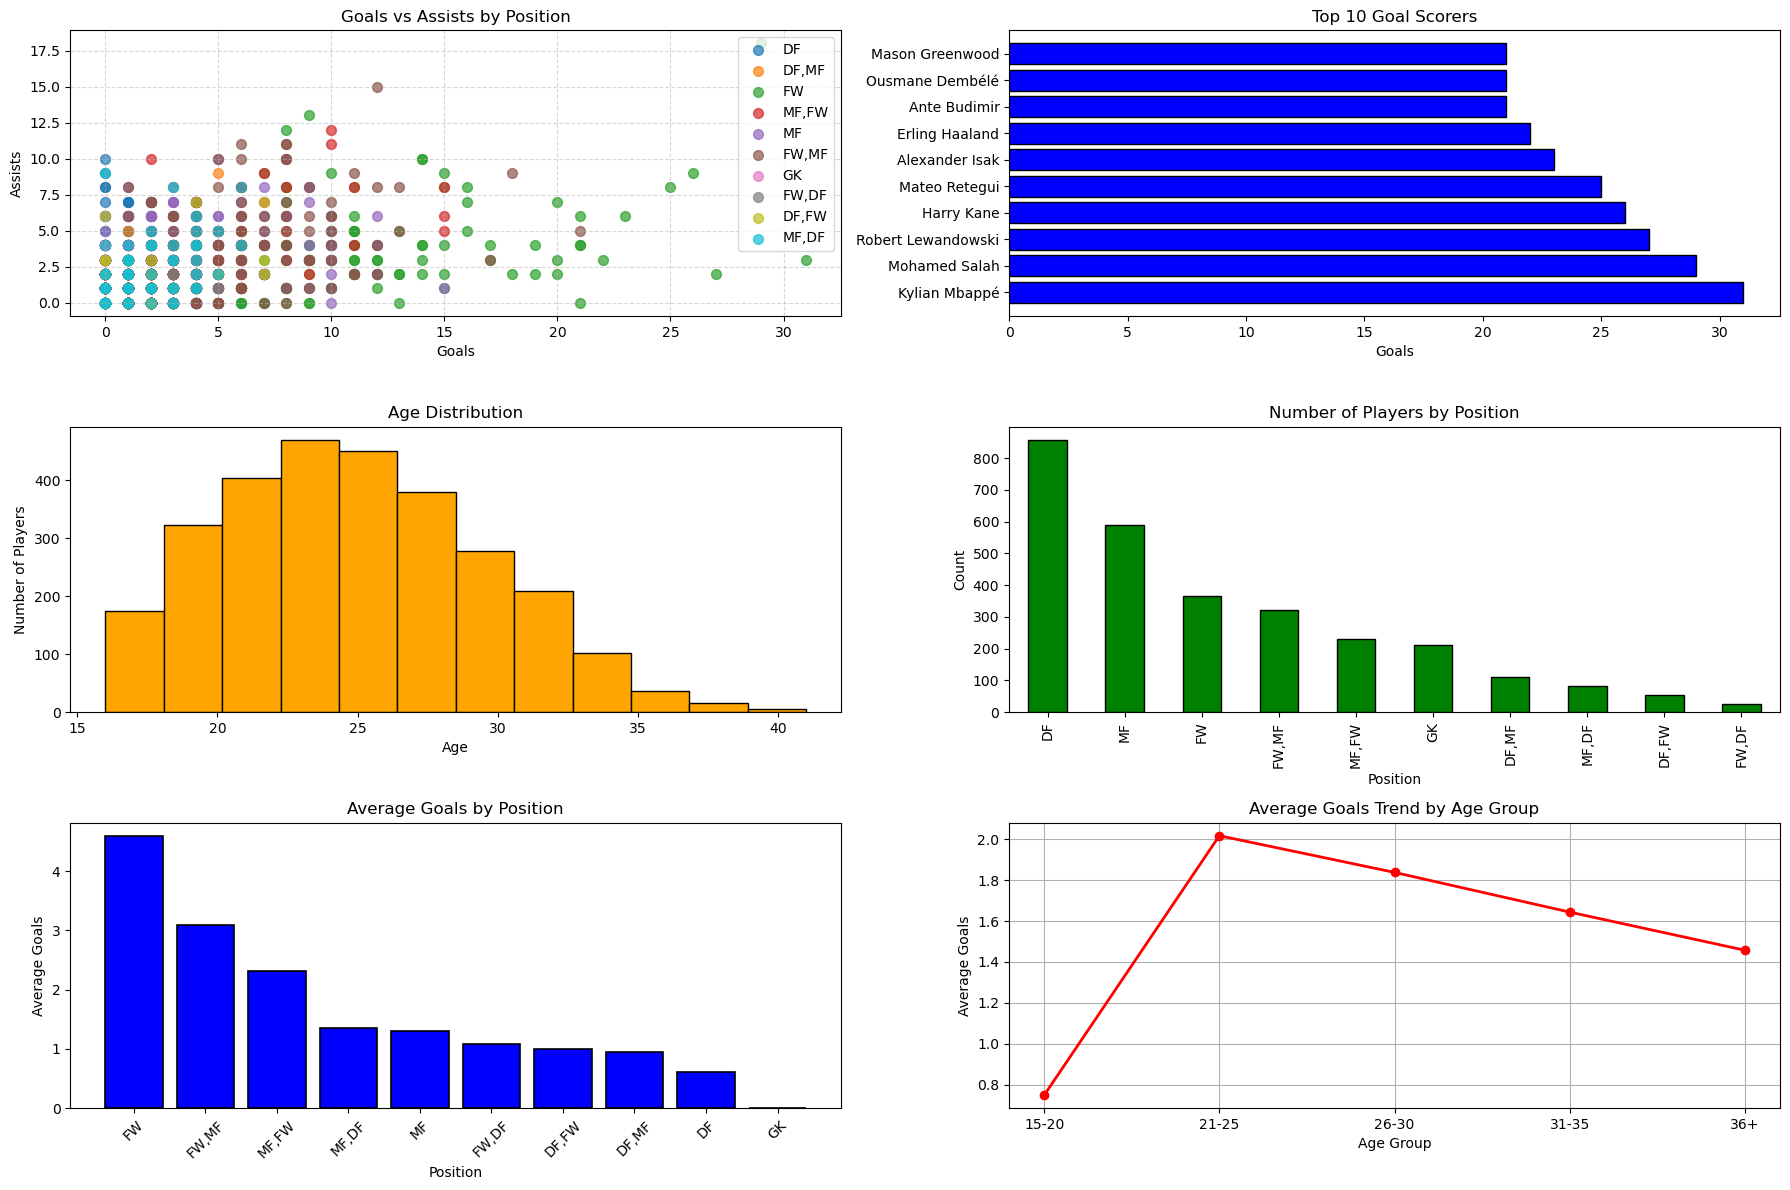

In [15]:
# ====================== VISUALIZATIONS ======================

plt.figure(figsize=(18, 12))

# 1. Scatter Plot - Relationship
plt.subplot(3, 2, 1)
for pos in df['Pos'].unique():
    subset = df[df['Pos'] == pos]
    plt.scatter(subset['Gls'], subset['Ast'], label=pos, alpha=0.7, s=50)
plt.xlabel("Goals")
plt.ylabel("Assists")
plt.title("Goals vs Assists by Position")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 2. Bar Chart - Top Scorers
plt.subplot(3, 2, 2)
top_scorers = df.nlargest(10, 'Gls')
plt.barh(top_scorers['Player'], top_scorers['Gls'], color='blue', edgecolor='black')
plt.xlabel("Goals")
plt.title("Top 10 Goal Scorers")

# 3. Histogram - Age Distribution
plt.subplot(3, 2, 3)
plt.hist(df['Age'], bins=12, color='orange', edgecolor='black')
plt.xlabel("Age")
plt.ylabel("Number of Players")
plt.title("Age Distribution")

# 4. Bar Chart - Players by Position
plt.subplot(3, 2, 4)
df['Pos'].value_counts().plot(kind='bar', color='green', edgecolor='black')
plt.title("Number of Players by Position")
plt.xlabel("Position")
plt.ylabel("Count")

# 5. Bar Chart - Average Goals by Position
plt.subplot(3, 2, 5)
avg_goals = df.groupby('Pos')['Gls'].mean().sort_values(ascending=False)
plt.bar(avg_goals.index, avg_goals.values, color='blue', edgecolor='black', linewidth=1.2)
plt.title("Average Goals by Position")
plt.xlabel("Position")
plt.ylabel("Average Goals")
plt.xticks(rotation=45)

# 6. Line Chart - Goals Trend by Age Group
plt.subplot(3, 2, 6)
age_goals = df.groupby('Age_Group')['Gls'].mean()
plt.plot(age_goals.index, age_goals.values, marker='o', linestyle='-', color='red', linewidth=2)
plt.title("Average Goals Trend by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Goals")
plt.grid(True)

plt.tight_layout()
plt.show()

In [16]:
# ====================== CORRELATION ANALYSIS ======================

print("=== Correlation Analysis ===")

# Select key numerical columns
corr_cols = ['Age', 'Gls', 'Ast', 'xG', 'Min', 'MP']
available_corr = [col for col in corr_cols if col in df.columns]

corr_matrix = df[available_corr].corr().round(3)
print("\nCorrelation Matrix:")
display(corr_matrix)



=== Correlation Analysis ===

Correlation Matrix:


,Age,Gls,Ast,xG,Min,MP
Age,1.000,0.065,0.078,0.077,0.240,0.233
Gls,0.065,1.000,0.554,0.937,0.402,0.447
Ast,0.078,0.554,1.000,0.579,0.485,0.523
xG,0.077,0.937,0.579,1.000,0.418,0.478
Min,0.240,0.402,0.485,0.418,1.000,0.915
MP,0.233,0.447,0.523,0.478,0.915,1.000


===  Linear Regression ===
Predicting Goals using xG, Shots on Target (SoT), and Minutes Played

Coefficients:
  xG: 0.7754
  SoT: 0.1157
  Min: -0.0001

Intercept: -0.1637
R-squared: 0.8880


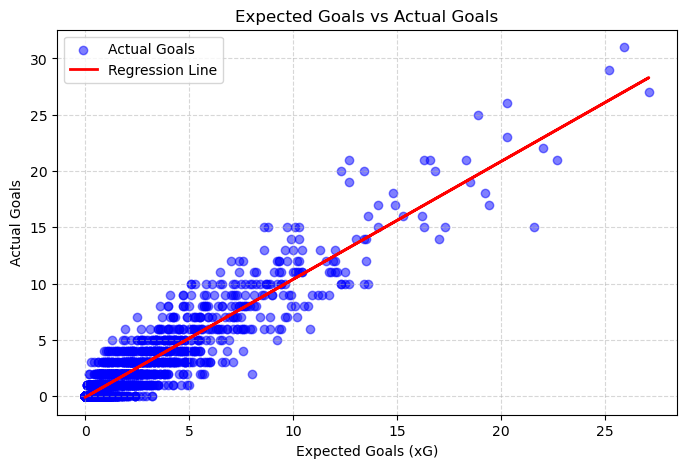

In [17]:
# ====================== LINEAR REGRESSION ======================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print("===  Linear Regression ===")
print("Predicting Goals using xG, Shots on Target (SoT), and Minutes Played")

# Strong predictors
features = ['xG', 'SoT', 'Min']
available_features = [col for col in features if col in df.columns]

X = df[available_features].dropna()
y = df.loc[X.index, 'Gls']

# Fit the multiple regression model
model = LinearRegression()
model.fit(X, y)

# Results
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

print("\nCoefficients:")
for feature, coef in zip(available_features, model.coef_):
    print(f"  {feature}: {coef:.4f}")

print(f"\nIntercept: {model.intercept_:.4f}")
print(f"R-squared: {r2:.4f}")

# =====  visuals (xG vs Goals) =====
X_simple = df[['xG']].dropna()
y_simple = df.loc[X_simple.index, 'Gls']

simple_model = LinearRegression()
simple_model.fit(X_simple, y_simple)

plt.figure(figsize=(8, 5))
plt.scatter(X_simple, y_simple, alpha=0.5, color='blue', label='Actual Goals')
plt.plot(X_simple, simple_model.predict(X_simple), color='red', linewidth=2, label='Regression Line')
plt.xlabel("Expected Goals (xG)")
plt.ylabel("Actual Goals")
plt.title("Expected Goals vs Actual Goals")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [18]:
# ====================== HYPOTHESIS TESTING (t-test) ======================

from scipy import stats

print("===  t-test ===")
print("Hypothesis: Is there a significant difference in average Goals between Forwards (FW) and Midfielders (MF)?")
print("H0: Mean Goals of FW = Mean Goals of MF")
print("H1: Mean Goals of FW ≠ Mean Goals of MF")

fw_goals = df[df['Pos'].str.contains('FW', na=False)]['Gls']
mf_goals = df[df['Pos'].str.contains('MF', na=False)]['Gls']

t_stat, p_value = stats.ttest_ind(fw_goals, mf_goals, equal_var=False)

print(f"\nt-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.5f}")

if p_value < 0.05:
    print("Result: Reject H0. There is a statistically significant difference in average Goals between Forwards and Midfielders.")
else:
    print("Result: Fail to reject H0. No significant difference found.")


===  t-test ===
Hypothesis: Is there a significant difference in average Goals between Forwards (FW) and Midfielders (MF)?
H0: Mean Goals of FW = Mean Goals of MF
H1: Mean Goals of FW ≠ Mean Goals of MF

t-statistic: 8.840
p-value: 0.00000
Result: Reject H0. There is a statistically significant difference in average Goals between Forwards and Midfielders.


In [19]:
# ====================== CHI-SQUARE TEST ======================

print("Chi-Square Test: Position vs High Goal Scoring")

# Create a simple high scorer category
df['High_Scorer'] = np.where(df['Gls'] >= 5, 'High', 'Low')

# Create contingency table
contingency = pd.crosstab(df['Pos'], df['High_Scorer'])
print("\nContingency Table:")
display(contingency)

# Run the test
chi2, p, dof, expected = stats.chi2_contingency(contingency)

print(f"\nChi-square value: {chi2:.3f}")
print(f"p-value: {p:.5f}")
print(f"Degrees of freedom: {dof}")

if p < 0.05:
    print("\nThere is a significant association between Position and high goal scoring.")
else:
    print("\nNo significant association was found between Position and high goal scoring.")

Chi-Square Test: Position vs High Goal Scoring

Contingency Table:


High_Scorer,High,Low
Pos,,
DF,8,849
"DF,FW",4,49
"DF,MF",4,106
FW,121,246
"FW,DF",2,22
"FW,MF",86,237
GK,0,212
MF,43,545
"MF,DF",4,77



Chi-square value: 405.491
p-value: 0.00000
Degrees of freedom: 9

There is a significant association between Position and high goal scoring.
